# Breast Cancer Dataset - Machine Learning Pipeline
This notebook handles data loading from sklearn, preprocessing, model training, evaluation, and saves the best model pipeline for production deployment.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


## 1. Load Dataset

In [2]:
print("Loading Breast Cancer dataset from sklearn...")
data = load_breast_cancer()

# Convert to pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['Target'].value_counts()}")

# Note: In sklearn's breast cancer dataset, 0 is Malignant, 1 is Benign.
# We will keep it as is.
TARGET = 'Target'

df.head()


Loading Breast Cancer dataset from sklearn...
Dataset shape: (569, 31)
Target distribution:
Target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Train-Test Split & Features Identification

In [3]:
# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# In this dataset, all features are numerical
numerical_features = X.columns.tolist()
print(f"Numerical features ({len(numerical_features)}): \n{numerical_features}")


Train set: (455, 30), Test set: (114, 30)
Numerical features (30): 
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


## 3. Preprocessing Pipeline

In [4]:
# Since all features are numerical, we just need a StandardScaler
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features)
    ])

print("Fitting preprocessor...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print(f"Transformed train shape: {X_train_preprocessed.shape}")
print("Preprocessing complete!")


Fitting preprocessor...
Transformed train shape: (455, 30)
Preprocessing complete!


## 4. Model Training

In [5]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model
print("Training complete!")


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training complete!


c:\Users\hp\django\MediSense\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:51:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 5. Evaluation & Confusion Matrices

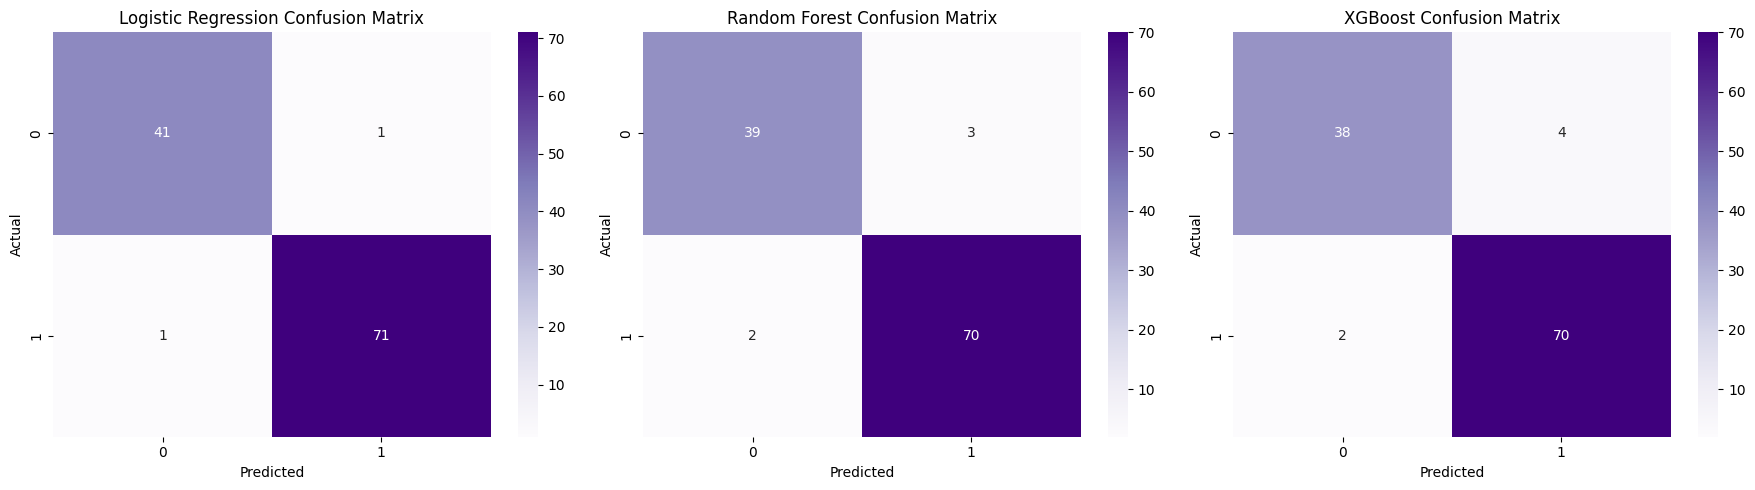

In [6]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 6. Model Comparison & Best Model Selection

In [7]:
# Create comparison report
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison Report:")
display(results_df)

# Select best model based on ROC AUC
best_model_name = results_df['ROC AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"\nBest Model selected based on ROC AUC: **{best_model_name}**")


Model Comparison Report:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
Random Forest,0.956140,0.958904,0.972222,0.965517,0.993386
XGBoost,0.947368,0.945946,0.972222,0.958904,0.994378



Best Model selected based on ROC AUC: **Logistic Regression**


## 7. Save Best Model Pipeline

In [8]:
# Bundle preprocessor and best model into a single deployable artifact
os.makedirs('../models', exist_ok=True)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

model_path = '../models/breast_cancer_model.pkl'
joblib.dump(full_pipeline, model_path)
print(f"Successfully saved complete {best_model_name} pipeline to {model_path}")


Successfully saved complete Logistic Regression pipeline to ../models/breast_cancer_model.pkl


## 8. Feature Importance Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_5140\2835554167.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')


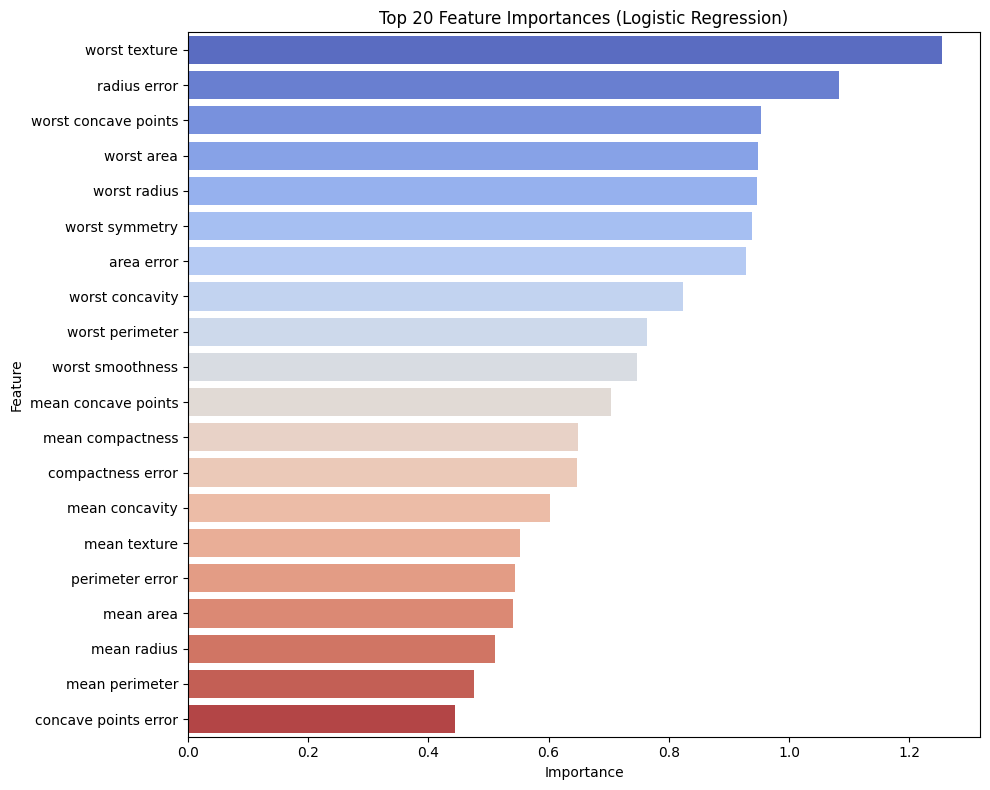

In [9]:
# Extract feature names
feature_names = numerical_features

if best_model_name == 'Logistic Regression':
    importances = np.abs(best_model.coef_[0])
else:
    importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')
plt.title(f'Top 20 Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()
